In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


df = pd.read_csv('Data/train.csv')
pd.options.display.float_format = '{:.2f}'.format
df.shape

(1503424, 18)

---

**EDA**

In [2]:
# Первый взгляд
df.head()

,item_id,user_id,region,city,parent_category_name,category_name,param_1,param_2,param_3,title,description,price,item_seq_number,activation_date,user_type,image,image_top_1,deal_probability
0,b912c3c6a6ad,e00f8ff2eaf9,Свердловская область,Екатеринбург,Личные вещи,Товары для детей и игрушки,Постельные принадлежности,NaN,NaN,Кокоби(кокон для сна),"Кокон для сна малыша,пользовались меньше месяц...",400.00,2,2017-03-28,Private,d10c7e016e03247a3bf2d13348fe959fe6f436c1caf64c...,1008.00,0.13
1,2dac0150717d,39aeb48f0017,Самарская область,Самара,Для дома и дачи,Мебель и интерьер,Другое,NaN,NaN,Стойка для Одежды,"Стойка для одежды, под вешалки. С бутика.",3000.00,19,2017-03-26,Private,79c9392cc51a9c81c6eb91eceb8e552171db39d7142700...,692.00,0.00
2,ba83aefab5dc,91e2f88dd6e3,Ростовская область,Ростов-на-Дону,Бытовая электроника,Аудио и видео,"Видео, DVD и Blu-ray плееры",NaN,NaN,Philips bluray,"В хорошем состоянии, домашний кинотеатр с blu ...",4000.00,9,2017-03-20,Private,b7f250ee3f39e1fedd77c141f273703f4a9be59db4b48a...,3032.00,0.43
3,02996f1dd2ea,bf5cccea572d,Татарстан,Набережные Челны,Личные вещи,Товары для детей и игрушки,Автомобильные кресла,NaN,NaN,Автокресло,Продам кресло от0-25кг,2200.00,286,2017-03-25,Company,e6ef97e0725637ea84e3d203e82dadb43ed3cc0a1c8413...,796.00,0.80
4,7c90be56d2ab,ef50846afc0b,Волгоградская область,Волгоград,Транспорт,Автомобили,С пробегом,ВАЗ (LADA),2110,"ВАЗ 2110, 2003",Все вопросы по телефону.,40000.00,3,2017-03-16,Private,54a687a3a0fc1d68aed99bdaaf551c5c70b761b16fd0a2...,2264.00,0.21


In [3]:
# Типы данных
df.dtypes

item_id                     str
user_id                     str
region                      str
city                        str
parent_category_name        str
category_name               str
param_1                     str
param_2                     str
param_3                     str
title                       str
description                 str
price                   float64
item_seq_number           int64
activation_date             str
user_type                   str
image                       str
image_top_1             float64
deal_probability        float64
dtype: object

<Axes: xlabel='parent_category_name'>

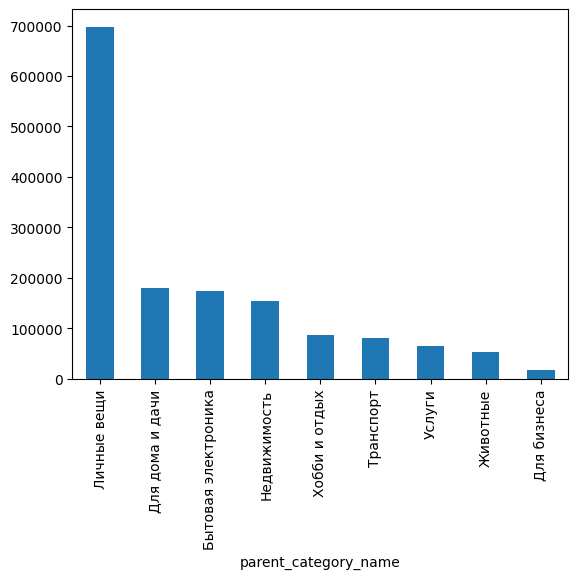

In [4]:
# Распределение классов по parent
df['parent_category_name'].value_counts().plot(kind='bar')

In [5]:
# Сколько всего классов в parent
df['parent_category_name'].nunique()

9

<Axes: xlabel='category_name'>

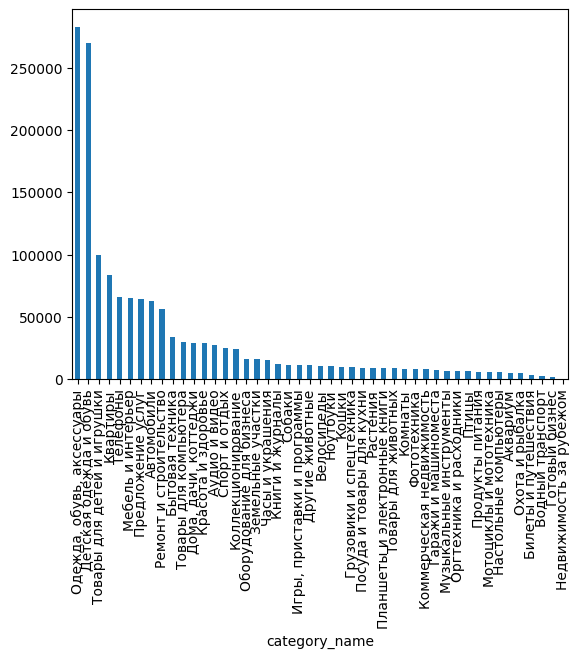

In [6]:
# Распределение классов по child 
df['category_name'].value_counts().plot(kind='bar')

In [7]:
# Сколько всего классов в child 
df['category_name'].nunique()

47

<Axes: >

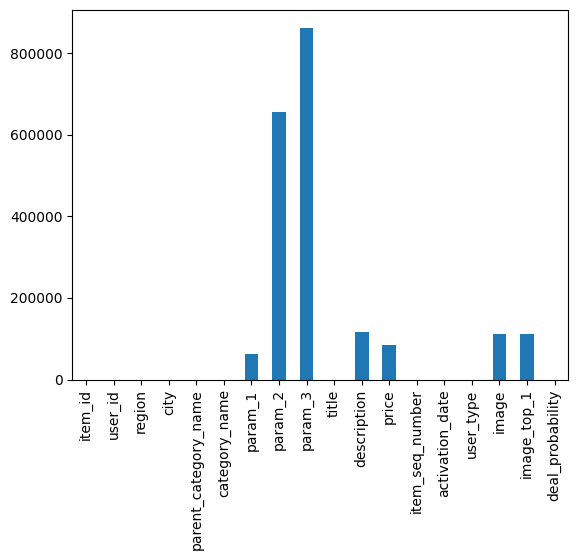

In [8]:
# Пропуски по колонкам
df.isnull().sum().plot(kind='bar')

In [9]:
df.sample(10)[['title', 'description', 'category_name']]

,title,description,category_name
1050169,"Комплект сдвижных, откатных ворот 3300х1900",Ворота сдвижные (откатные). Размер проема 3300...,Ремонт и строительство
147896,Кастрюлька Варшава,забирать в центре,Посуда и товары для кухни
1096258,Платье фирменное качественное р. 104-110,платье фирменное качественное р. 104-110,Детская одежда и обувь
936316,В дар деревце розы крупные листья красивый,организация дарит деревце розы причина переез...,Растения
606799,Adidas sojuz. Винтаж. 1984г. Оригинал. 39размер,Продам оригинальные шиповки Adidas sojuz. Г...,"Одежда, обувь, аксессуары"
717321,Юбка,OGGI,"Одежда, обувь, аксессуары"
1366511,"Комната 15 м² в 2-к, 1/5 эт.",Сдаётся комната для одного человека в двухкомн...,Комнаты
241217,Вечернее / выпускное платье,Продам вечернее / выпускное платье. Было сшито...,"Одежда, обувь, аксессуары"
218922,50 копеек 50 лет Советской власти продажа,Продам 50 копеек 50 лет Советской власти 1967г...,Коллекционирование
88677,Спортивный костюм,"Спортивный костюм размер 92, на флисе. Смотрет...",Детская одежда и обувь


In [10]:
df['title_len'] = df['title'].str.len()
df['desc_len'] = df['description'].str.len()
df[['title_len', 'desc_len']].describe()


,title_len,desc_len
count,1503424.00,1387148.00
mean,21.39,192.89
std,10.99,295.13
min,1.00,1.00
25%,13.00,50.00
50%,20.00,96.00
75%,28.00,200.00
max,56.00,3212.00


<Axes: >

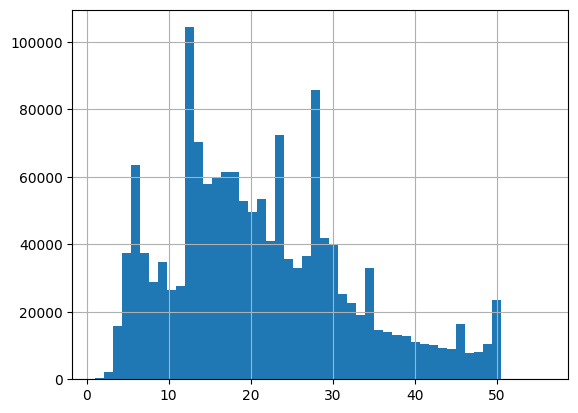

In [11]:
df['title_len'].hist(bins=50)

<Axes: >

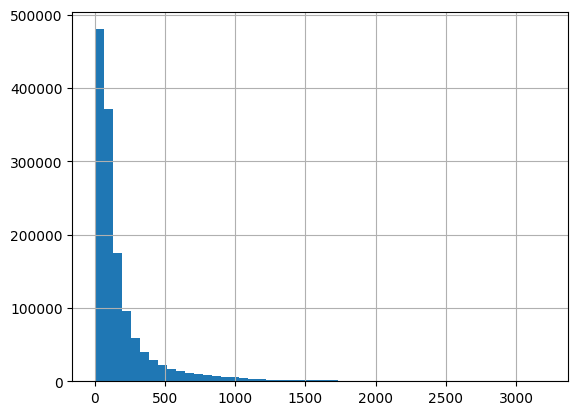

In [12]:
df['desc_len'].hist(bins=50)

In [13]:
# Сколько пустых описаний = 7%
df['description'].isnull().mean() * 100

np.float64(7.734079008982163)

In [14]:
# 10 больших классов
df['category_name'].value_counts().head(10)

category_name
Одежда, обувь, аксессуары     282753
Детская одежда и обувь        270359
Товары для детей и игрушки     99747
Квартиры                       83670
Телефоны                       65944
Мебель и интерьер              65035
Предложение услуг              64385
Автомобили                     62494
Ремонт и строительство         56201
Бытовая техника                33705
Name: count, dtype: int64

In [15]:
# 10 малых классов 
df['category_name'].value_counts().tail(10)

category_name
Птицы                      6447
Продукты питания           5781
Мотоциклы и мототехника    5771
Настольные компьютеры      5450
Аквариум                   4840
Охота и рыбалка            4524
Билеты и путешествия       3108
Водный транспорт           2180
Готовый бизнес             2028
Недвижимость за рубежом     117
Name: count, dtype: int64

Разница между большим и меньшим классом = в ~2417 раз 

In [16]:
# Топ-5 классов занимают 53% от всего датасета 
df['category_name'].value_counts().head(5).sum() / len(df) * 100

np.float64(53.37635956323699)

In [17]:
# Сколько "child" в родительском классе 
df.groupby('parent_category_name')['category_name'].nunique()

parent_category_name
Бытовая электроника    9
Для бизнеса            2
Для дома и дачи        6
Животные               6
Личные вещи            5
Недвижимость           7
Транспорт              4
Услуги                 1
Хобби и отдых          7
Name: category_name, dtype: int64

In [18]:
# Сколько объявлений в parent классе
df['parent_category_name'].value_counts()

parent_category_name
Личные вещи            697623
Для дома и дачи        178823
Бытовая электроника    173008
Недвижимость           153190
Хобби и отдых           86011
Транспорт               79839
Услуги                  64385
Животные                52470
Для бизнеса             18075
Name: count, dtype: int64

Сильный дисбаланс топ и малого класса: 697k и 18k = в ~38 раз 

In [19]:
# К какому parent принадлежит child 
df.groupby('parent_category_name')['category_name'].unique()

parent_category_name
Бытовая электроника    [Аудио и видео, Товары для компьютера, Телефон...
Для бизнеса                   [Оборудование для бизнеса, Готовый бизнес]
Для дома и дачи        [Мебель и интерьер, Ремонт и строительство, По...
Животные               [Собаки, Товары для животных, Другие животные,...
Личные вещи            [Товары для детей и игрушки, Одежда, обувь, ак...
Недвижимость           [Квартиры, Дома, дачи, коттеджи, Комнаты, Комм...
Транспорт              [Автомобили, Мотоциклы и мототехника, Грузовик...
Услуги                                               [Предложение услуг]
Хобби и отдых          [Коллекционирование, Спорт и отдых, Музыкальны...
Name: category_name, dtype: object

47 child-классов. Топ-5 = 53% датасета. Самый частый: Одежда (282k). Самый редкий: Недвижимость за рубежом (117). Только 1 класс <1000 объявлений.